# SpectFbCalc Tutorial

## This notebook demonstrates how to calculate broadband and spectral climate feedbacks using the provided sample data.

To use the notebook download kernels: radiative kernels (spectral and broadband) are hosted separately on Zenodo
and Mendeley Data and are not included in the repository. 
Download them with:
```bash
cd spectfbcalc/
nohup python download_kernels.py > download_kernels.log 2>&1 &
disown
```
This runs in the background. Track progress with:
```bash
tail -f download_kernels.log
```
If interrupted, simply re-run the same command: already-downloaded files are skipped automatically.

## Import libraries and modules

In [1]:
import spectfbcalc_lib as sfc
from climtools import climtools_lib as ctl 
import output_lib as out

No DISPLAY variable set. Switching to agg backend


In [2]:
# test libraries import
sfc.mytestfunction()

test!


In [3]:
ctl.datestamp()

'2026-09-23T15:57:05'

In [4]:
import sys
import os
import glob

import numpy as np
import xarray as xr

from matplotlib import pyplot as plt
import matplotlib.cbook as cbook

%matplotlib inline

### OPTIONAL: launch workers to speed up the process (needs a SLURM scheduler)

In [ ]:
# set your hpc account
hpc_account = ''

In [ ]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=4,
    memory="64GB",
    processes=4,
    walltime="01:00:00",
    job_extra_directives=[
        f"--account={hpc_account}",
        "--qos=np"
    ]
)

# dask scale to desired number of workers
cluster.scale(jobs=4)  # This submits 4 SLURM jobs

# connect client
client = Client(cluster)

In [7]:
print(client.dashboard_link)

http://10.100.192.102:8787/status


In [8]:
print(client)

<Client: 'tcp://10.100.192.102:43105' processes=0 threads=0, memory=0 B>


In [9]:
import dask.array as da
x = da.random.random((20000, 20000), chunks=(1000, 1000))
result = (x + x.T).mean().compute()
print(result)

# to check the status of the workers and the number of tasks executed, you can use the following code:
info = client.scheduler_info()['workers']
for addr, w in info.items():
    print(addr, "- tasks:", w.get('metrics', {}).get('task_counts', 'n/a'))

0.999973925064505
tcp://10.100.136.142:36057 - tasks: {'executing': 1, 'ready': 1}
tcp://10.100.136.142:42245 - tasks: {'executing': 1, 'ready': 1}
tcp://10.100.136.142:42665 - tasks: {'executing': 1, 'ready': 1}
tcp://10.100.136.142:45467 - tasks: {'executing': 1, 'ready': 1}
tcp://10.100.136.78:34517 - tasks: {'released': 22, 'memory': 6, 'executing': 1, 'ready': 1}


## Load configuration

In [31]:
config_file='../config_template.yaml'
config = sfc.load_config(config_file, variable_mapping_file = None)
ref_dir = config['file_paths']['reference_dataset']
exp_dir = config['file_paths']['experiment_dataset']
cart_out_huang = os.path.join(config['file_paths']['output'], 'HUANG/')
cart_out_spect = os.path.join(config['file_paths']['output'], 'SPECTRAL/')
os.makedirs(cart_out_huang, exist_ok=True)
os.makedirs(cart_out_spect, exist_ok=True)

Time range for climatology: all
Time range for experiment: all


## Broadband feedbacks (HUANG kernels)

### Tutorial Step-by-Step
### Load the control experiment object directly, data are already preprocessed and remapped.

In [14]:
ker = 'HUANG'  
raw_variables = {"hus", "rlut", "rsdt", "rlutcs", "rsus", "rsds", "rsut", "rsutcs", "ta", "tas", "ts"}

control_h = sfc.Experiment('PI', orig_dir='', remap_dir=ref_dir, raw_variables=raw_variables, variable_mapping=config['variable_mapping'], file_dict={})
experiment_h = sfc.Experiment('4x', orig_dir='', remap_dir=exp_dir, raw_variables=raw_variables, variable_mapping=config['variable_mapping'], file_dict={})
control_h.load_remapped()
experiment_h.load_remapped()

### Inizialized kernel object

In [19]:
kernel = sfc.Kernel(ker, config=config)
k = kernel.kernel[('clr', 't')]

control_h.check_coords()
control_h.vertical_interp(k)
experiment_h.check_coords()
experiment_h.vertical_interp(k)

Loading kernel: HUANG
check vertical dimension
Converting vertical coordinates from Pa to hPa
check vertical dimension
Converting vertical coordinates from Pa to hPa


### Compute climate anomalies (dT) and radiative anomalies (dRt)

In [20]:
# compute albedo
control_h.check_albedo()
experiment_h.check_albedo()

# check water vapor
control_h.check_vars('water-vapor', kernel.wv_name)
experiment_h    .check_vars('water-vapor', kernel.wv_name)

# compute net TOA
control_h.compute_net_TOA()
experiment_h.compute_net_TOA()

Computing albedo from rsus and rsds
Computing albedo from rsus and rsds
wv_name:hus_log
Applying log to hus
wv_name:hus_log
Applying log to hus
Creating Net TOA variables
Creating Net TOA variables


In [21]:
# compute climate anomalies (4x - PI)
sfc.compute_anomalies(experiment_h, control_h, method=config['anomaly_method'], time_range_clim=config['time_range_clim'])

In [22]:
# compute radiative anomalies one by one
sfc.Rad_anomaly_planck_surf(experiment_h, kernel, cart_out_huang, save_pattern=True)

Processing clr
in save patt
Processing cld
in save patt


{('clr',
  'planck-surf'): <xarray.DataArray 'planck-surf' (time: 120)> Size: 480B
 array([-8.335281 , -8.017288 , -8.114071 , -7.880681 , -7.9920926,
        -7.801392 , -8.078355 , -8.416003 , -8.736281 , -8.736133 ,
        -8.442128 , -8.036624 , -7.902701 , -7.8795877, -7.960437 ,
        -7.5260005, -7.801773 , -7.744064 , -7.7248764, -8.2108555,
        -8.663179 , -8.880271 , -8.256118 , -7.8897715, -8.002652 ,
        -7.713234 , -7.7240777, -7.770802 , -7.7829165, -7.7825828,
        -7.881605 , -8.372737 , -8.854241 , -8.921097 , -8.373947 ,
        -8.14831  , -8.140589 , -8.099382 , -7.952182 , -8.007599 ,
        -7.998168 , -8.04907  , -8.122732 , -8.484953 , -8.963572 ,
        -8.995605 , -8.613702 , -8.39777  , -8.190524 , -8.198689 ,
        -8.203735 , -7.939399 , -8.041093 , -8.059039 , -8.206455 ,
        -8.758877 , -9.138838 , -9.172501 , -8.766376 , -8.40118  ,
        -8.2302685, -8.312039 , -8.070746 , -7.999657 , -8.08791  ,
        -7.966696 , -7.9025745, -

In [23]:
sfc.Rad_anomaly_albedo(experiment_h, kernel, cart_out_huang, save_pattern=True)

{('clr',
  'albedo'): <xarray.DataArray 'albedo' (time: 120)> Size: 480B
 array([ 1.823754 ,  2.3261895,  4.115865 ,  7.7061396, 11.963321 ,
         9.414411 ,  4.2797976,  2.5338461,  2.9442196,  4.219216 ,
         4.121585 ,  2.6480224,  1.8629254,  2.2625003,  4.328302 ,
         7.6440873, 11.128573 ,  9.370162 ,  4.2555485,  2.567363 ,
         2.9917946,  4.320152 ,  4.0267572,  2.4576702,  1.9335696,
         2.1430717,  4.0022054,  8.307392 , 12.149268 ,  9.428445 ,
         4.254505 ,  2.5633945,  3.0362883,  4.3275485,  4.1915536,
         2.6383572,  2.12695  ,  2.7695992,  4.7139297,  8.369231 ,
        12.175493 ,  9.384715 ,  4.2279563,  2.553343 ,  3.0551171,
         4.3883247,  4.2204947,  2.562309 ,  1.5086857,  2.3140562,
         4.3604283,  8.255946 , 11.833408 ,  9.331665 ,  4.2455335,
         2.54586  ,  3.142612 ,  4.574203 ,  4.4795485,  2.713378 ,
         1.949331 ,  2.7923715,  4.633326 ,  8.692322 , 12.280648 ,
         9.391384 ,  4.2168603,  2.4933147,

In [24]:
sfc.Rad_anomaly_planck_atm_lr(experiment_h, kernel, cart_out_huang, save_pattern=True)

Processing clr


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 23.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 23.87 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Processing cld


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 23.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 23.87 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{('clr',
  'planck-atmo'): <xarray.DataArray 'planck-atmo' (time: 120)> Size: 960B
 array([-15.25410574, -14.95038386, -14.98134219, -14.87239709,
        -15.34018747, -16.09831409, -17.62098426, -18.02970235,
        -17.57458465, -16.50099334, -15.55646158, -14.50539789,
        -14.20005527, -14.26969054, -14.28104727, -13.95660366,
        -14.75221661, -15.66239508, -16.72925471, -17.47768108,
        -17.21522511, -16.44894727, -15.17611956, -14.26144808,
        -14.21433695, -13.92835638, -13.9262004 , -14.20482015,
        -14.81376291, -15.82739762, -17.06513741, -17.73128614,
        -17.49523169, -16.57759219, -15.09837263, -14.57081218,
        -14.56566636, -14.6043947 , -14.48422028, -14.73329833,
        -15.16253042, -16.4124552 , -17.54914434, -18.02027105,
        -17.83985903, -16.87026514, -15.78789451, -15.10071175,
        -14.96274054, -15.20004705, -15.17112025, -14.87106964,
        -15.46343113, -16.48515785, -17.76599876, -18.52848649,
        -18.07295274,

In [25]:
sfc.Rad_anomaly_wv(experiment_h, control_h, kernel, cart_out_huang, save_pattern=True)

Processing clr


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 46.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 34.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Before WV computation


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 34.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed


...

Before WV computation


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 34.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 34.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 46.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{('clr',
  'water-vapor-lw'): <xarray.DataArray 'water-vapor-lw' (time: 120)> Size: 960B
 array([13.52699009, 13.5956154 , 14.08567621, 14.05240988, 13.81959614,
        14.79323964, 15.08724396, 15.43212346, 15.54865143, 14.71047647,
        13.78485197, 12.92070603, 12.43774705, 12.34591936, 12.13306224,
        12.31450059, 13.01937147, 13.31416192, 14.21092287, 14.62155507,
        14.64213955, 14.07734447, 13.4341596 , 12.9707534 , 12.50265525,
        11.92992997, 12.0531045 , 12.37721612, 12.90402631, 13.47812253,
        13.79695038, 14.69519552, 14.27789745, 13.81944881, 13.36282969,
        12.7961517 , 12.94564212, 12.53990577, 13.05992592, 13.29320393,
        13.28401814, 14.45535601, 14.73003966, 15.05273751, 14.81966684,
        14.18755832, 13.79833431, 13.24185751, 13.39625688, 13.63073661,
        13.80609942, 13.98569542, 14.31369842, 14.92485024, 15.28585446,
        15.49668043, 15.72443159, 14.68242843, 13.60371572, 13.46986091,
        12.95509377, 12.51110508, 1

In [26]:
sfc.Rad_anomaly_cloud(experiment_h, cart_out_huang, save_pattern=True)

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 10.66 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 10.66 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distri

<xarray.DataArray 'cloud' (time: 120)> Size: 960B
array([ 0.60349041, -0.6914589 , -1.81040258, -2.47436752, -2.03326098,
        1.19456228,  4.60665732,  3.72451372,  2.13285297, -0.06743977,
        1.07061981,  0.06296432, -0.08710772,  0.59212588,  0.53068028,
       -0.72097105,  0.0769898 ,  1.75973592,  4.5534251 ,  4.50893478,
        2.28626682,  0.8850874 ,  0.62884197,  0.35777491,  0.77845792,
        0.50827872,  0.23048151, -0.30309995, -0.6326437 ,  1.34252579,
        3.93940863,  3.77124229,  1.6524128 ,  0.555197  ,  0.19736   ,
        1.53900548,  0.57691935,  0.06003758,  0.26036849, -0.69033772,
       -1.8112729 ,  2.44905606,  3.61605786,  3.01121782,  1.76036319,
        0.05326924,  0.46723073,  0.60965256,  1.16553259,  0.16264754,
       -0.57511776, -2.42321342, -1.30031054,  1.72311284,  4.39980444,
        4.57755163,  2.03021948,  1.01235291,  1.24311592,  1.4601003 ,
        0.80591218,  1.3435497 ,  0.65535095, -0.39066862, -0.75637971,
        2.15970365,  4.65992881,  3.32789497,  1.63987662,  0.40029949,
        0.50579943,  1.55929757,  1.85985918,  0.95879859,  0.48886133,
       -0.65071025, -1.03978206,  1.32009396,  4.88504978,  3.51974025,
        1.87035609,  1.12175887,  0.54761098,  1.35054778,  0.35031122,
        0.51211204, -0.61226979, -0.92735214, -1.4766082 ,  1.65166967,
        2.84623207,  3.04539425,  1.92092495,  0.41388336,  0.52836412,
        0.89159326, -0.03871062,  0.67344571, -1.38105645, -1.61317234,
       -1.98691463,  1.09283849,  3.0027755 ,  3.25990182,  1.5295668 ,
        0.164031  ,  0.44462726,  0.7182392 ,  0.61081421,  0.93745868,
       -0.1471907 , -1.23835483, -1.69378539,  1.99562357,  4.28929331,
        3.65734482,  2.48856446,  0.28537544,  0.45387554,  0.58226037])
Coordinates:
  * time     (time) object 960B 2005-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 960B 2.0 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
    month    (time) int64 960B 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    regrid_method:  bilinear

### Compute feedbacks

In [27]:
# compute all feedbacks 
fb_huang = sfc.calc_fb_from_exp(experiment_h, control_h, kernel, cart_out_huang, save_pattern=config['save_pattern'], num_year_fb =config['num_year_regr'])

feedback calculation...
Computing spatial feedback pattern for clr-planck-surf...
Computing spatial feedback pattern for clr-planck-atmo...
Computing spatial feedback pattern for clr-lapse-rate...
Computing spatial feedback pattern for clr-water-vapor...
Computing spatial feedback pattern for clr-albedo...
Computing spatial feedback pattern for cld-planck-surf...
Computing spatial feedback pattern for cld-planck-atmo...
Computing spatial feedback pattern for cld-lapse-rate...
Computing spatial feedback pattern for cld-water-vapor...
Computing spatial feedback pattern for cld-albedo...
Computing spatial feedback pattern for cld-cloud...
Computing spatial feedback pattern for cld-cloud-lw...
Computing spatial feedback pattern for cld-cloud-sw...


In [28]:
# compute interannual feedbacks 
fb_huang_interannual = sfc.calc_fb_interannual(experiment_h, control_h, kernel, cart_out_huang)

feedback calculation...


## Spectral feedbacks 

To compute spectral feedbacks, the tool needs to remap the data to the high-resolution spectral grid. We can use the wrapper `preprocess_data` to automate loading, remapping, and anomaly computation in a single step.

### Preprocess data

In [32]:
ref_dir = config['file_paths']['reference_dataset']
exp_dir = config['file_paths']['experiment_dataset']

spectral_vars = ["hus", "rlut", "rsdt", "rlutcs", "ta", "tas", "ts"]

control_files = {var: glob.glob(f"{ref_dir}/{var}_*.nc") for var in spectral_vars}
exp_files = {var: glob.glob(f"{exp_dir}/{var}_*.nc") for var in spectral_vars}

In [33]:
control_sp, experiment_sp, kernel_sp = sfc.preprocess_data(config=config, ker='SPECTRAL', control_file_dict=control_files, exp_file_dict=exp_files)

Loading kernel: SPECTRAL
<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([   1.,   10.,   20.,   30.,   50.,   70.,  100.,  150.,  200.,  250.,
        300.,  400.,  500.,  600.,  700.,  850.,  925., 1000.])
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
Reordering vertical levels from surf to TOA
<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([1000.,  925.,  850.,  700.,  600.,  500.,  400.,  300.,  250.,  200.,
        150.,  100.,   70.,   50.,   30.,   20.,   10.,    1.])
Coordinates:
  * plev     (plev) float64 144B 1e+03 925.0 850.0 700.0 ... 30.0 20.0 10.0 1.0
<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([   1.,   10.,   20.,   30.,   50.,   70.,  100.,  150.,  200.,  250.,
        300.,  400.,  500.,  600.,  700.,  850.,  925., 1000.])
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
Reordering vertical levels from surf to TOA
<xarray.DataArray 'plev' (plev: 18)> Size

/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:451: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  with xr.open_dataset(self.file_dict[first_var][0]) as ds_check:
/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:451: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  with xr.open_dataset(self.file_dict[first_var][0]) as ds_check:


rsdt
tas
ts
Regridding...
Regridding completed in 0:00:07.900555
Regridding...
Regridding completed in 0:00:00.271980
Regridding...
Regridding completed in 0:00:00.266603
Regridding...
Regridding completed in 0:00:00.257495
Regridding...
Regridding completed in 0:00:00.265510
Regridding...
Regridding completed in 0:00:00.260291
Regridding...
Regridding completed in 0:00:00.261222
Saving remapped to disk
hus
rlutcs
ta
rlut
rsdt
tas
ts
check vertical dimension
Converting vertical coordinates from Pa to hPa
Lat range to apply: {'start': None, 'end': None}
Lon range to apply: {'start': None, 'end': None}

 -------> Loading experiment
Remapped data not found in: ../output_test/test/remapped_SPECTRAL, computing...
Loading raw data...
hus
rlutcs
ta
rlut
rsdt
tas
ts
Regridding...
Regridding completed in 0:00:00.264063
Regridding...
Regridding completed in 0:00:00.252915
Regridding...
Regridding completed in 0:00:00.257645
Regridding...
Regridding completed in 0:00:00.256958
Regridding...
Regri

### Calculate spectral feedbacks 

In [34]:
fb_spectral = sfc.calc_fb_spectral(
    experiment=experiment_sp, 
    kernel=kernel_sp, 
    cart_out=cart_out_spect,
    control=control_sp,
    save_pattern=False,
    num_year_fb=config['num_year_regr']
)

planck surf
Processing clr
Processing cld
planck atm
Processing clr


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 18.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Processing cld


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 18.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


albedo
Skipping albedo feedback for SPECTRAL kernels (not defined).
w-v
Processing clr
Before WV computation


...

Computed lin part: <xarray.DataArray ()> Size: 8B
array(5.91885214e-10)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.02520898)
Attributes:
    regrid_method:  bilinear
Processing cld
Before WV computation


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 18.08 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed log part: <xarray.DataArray ()> Size: 8B
array(3.07154198e-07)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.01982309)
Attributes:
    regrid_method:  bilinear


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 18.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed lin part: <xarray.DataArray ()> Size: 8B
array(5.92040782e-10)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.02111128)
Attributes:
    regrid_method:  bilinear


## Save output and plot example

### Broadband

In [35]:
import xarray as xr

out_dir = config['file_paths']['output']  # Replace with your desired output directory

out_txt_huang = os.path.join(out_dir, 'res_fb_huang.txt')
out_nc_huang = os.path.join(out_dir, 'res_fb_patterns_huang.nc')

# Salva
out.save_feedback_output(fb_huang, out_path_txt=out_txt_huang, out_path_nc=out_nc_huang)

Saved feedback coefficients to ../output_test/res_fb_huang.txt, new one
Saved feedback spatial patterns to ../output_test/res_fb_patterns_huang.nc


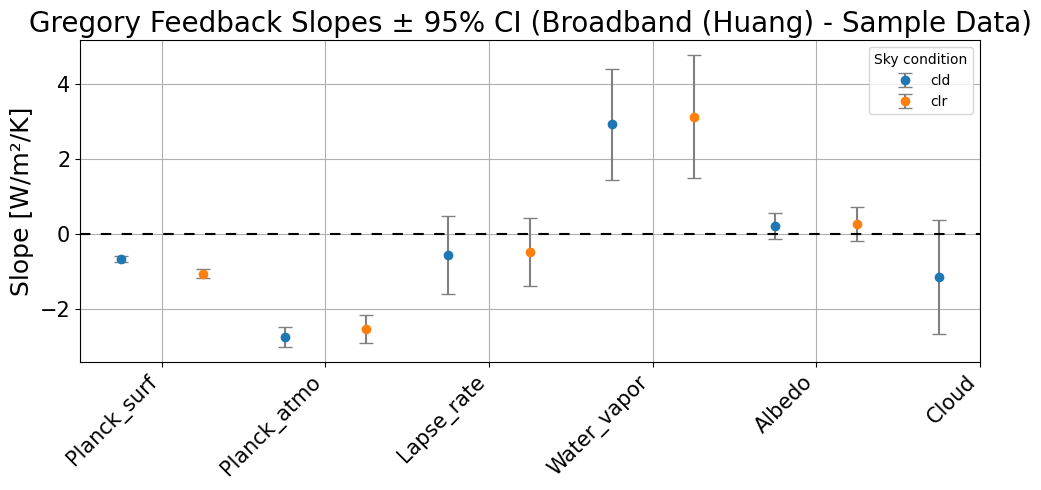

In [36]:
# Gregory plot
out.plot_feedback_slope(out_txt_huang, sim_label="Broadband (Huang) - Sample Data", save_path=out_dir+"gregory_huang.png")

In [37]:
# Spatial maps of feedback patterns
ds_patterns_huang = xr.open_dataset(out_nc_huang)
out.save_all_fb_patterns_to_pdf(
    ds=ds_patterns_huang, 
    output_folder=out_dir, 
    pdf_name="spatial_maps_huang.pdf",
    run_label="Broadband" 
)

⚠️  clr_cloud_slope or clr_cloud_stderr not found, skipping.
Combined feedback PDF saved to: ../output_test/spatial_maps_huang.pdf


Plot saved: ../output_test/budget_closure_clr.png


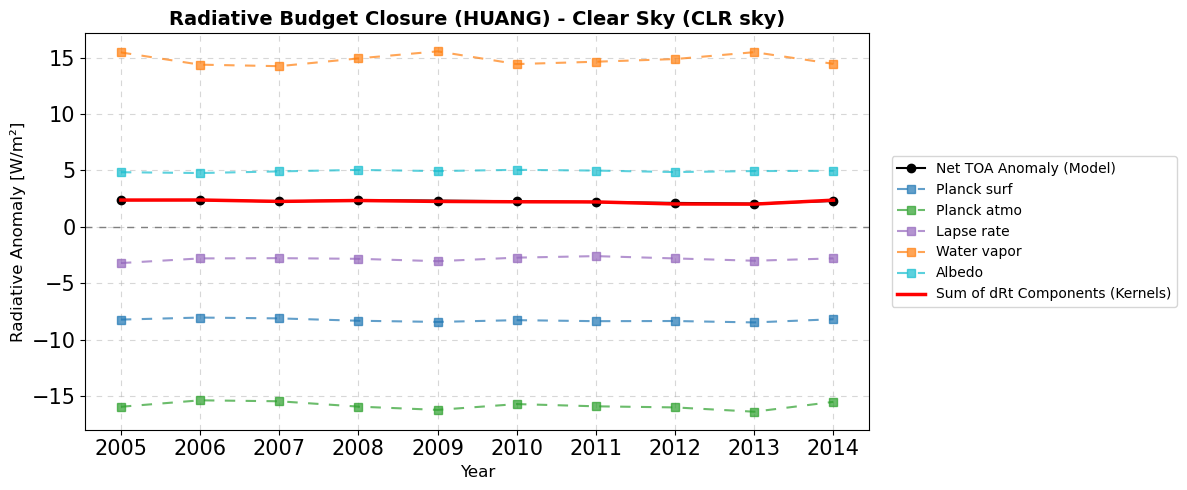

Plot saved: ../output_test/budget_closure_cld.png


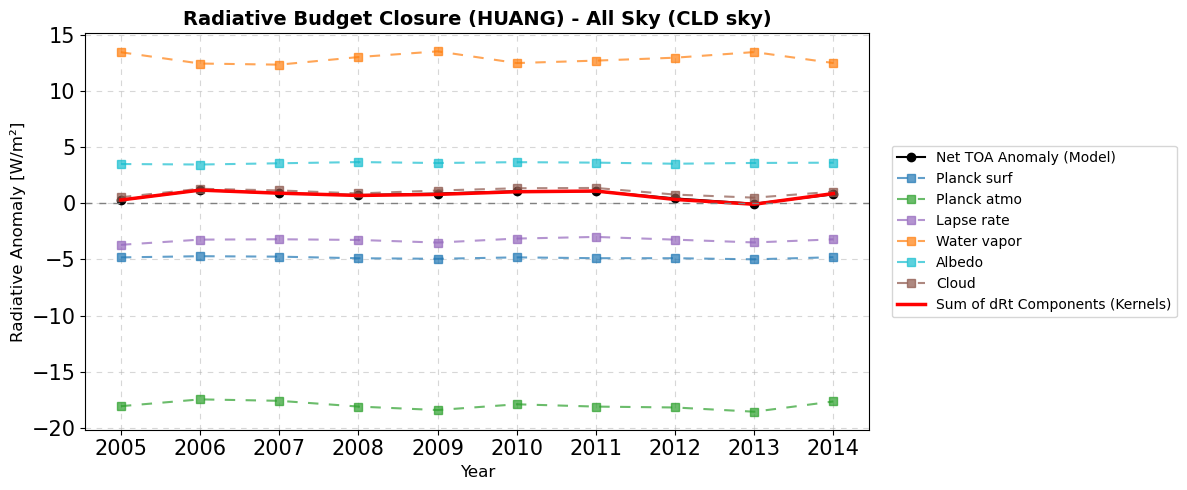

In [38]:
# Radiative Budget Closure
dRt_dict = sfc.open_dRt(cart_out_huang, names=sfc.dRt_all + sfc.dRt_all_cloud)

# Clear sky
out.plot_toa_anomaly(
    experiment=experiment_h,  
    dRt_dict=dRt_dict, 
    title="Radiative Budget Closure (HUANG) - Clear Sky", 
    sky="clr", 
    output_file=out_dir + "budget_closure_clr.png"
)

# All sky
out.plot_toa_anomaly(
    experiment=experiment_h, 
    dRt_dict=dRt_dict, 
    title="Radiative Budget Closure (HUANG) - All Sky", 
    sky="cld", 
    output_file=out_dir + "budget_closure_cld.png"
)

### Spectral 

Spectral feedbacks plot saved: ../output_test/spectral_feedbacks_clr.png


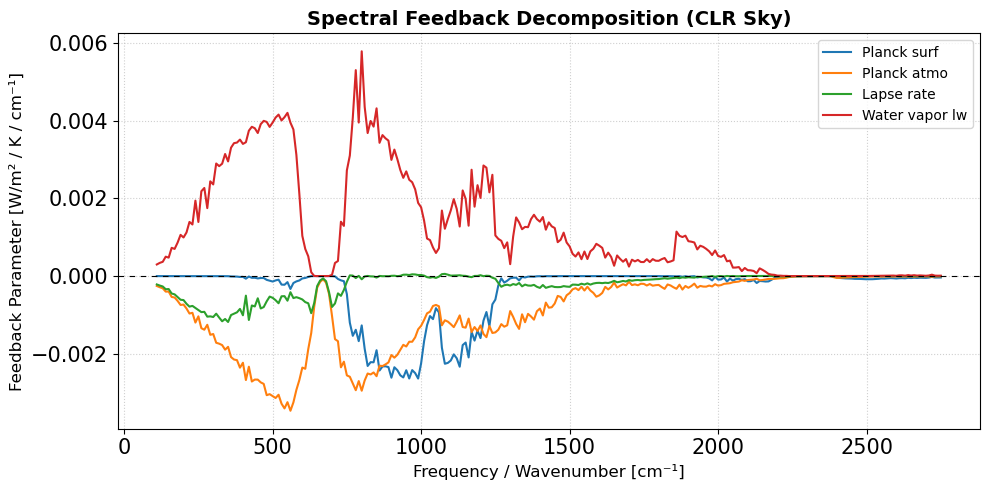

Spectral feedbacks plot saved: ../output_test/spectral_feedbacks_cld.png


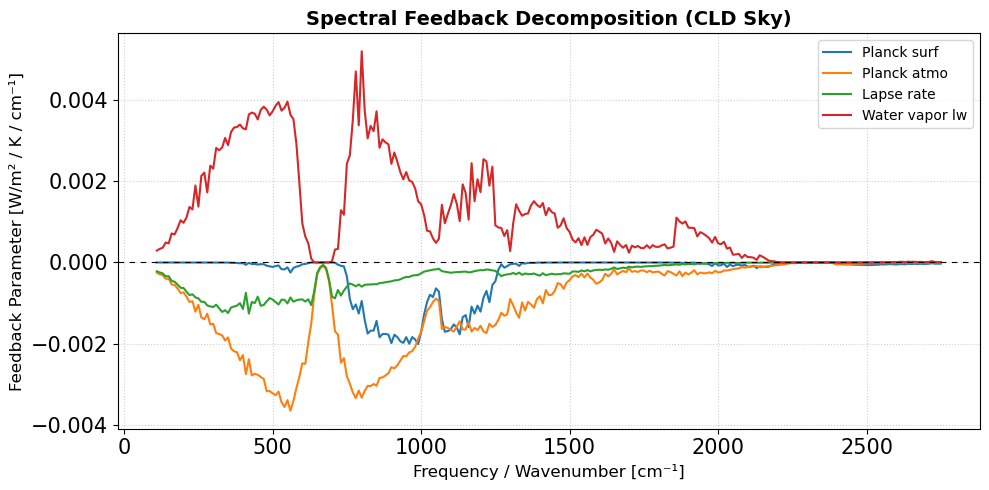

In [39]:
out_dir = config['file_paths']['output']

# Spectral Feedback Plot
# Clear sky
out.plot_spectral_feedbacks(
    input_dir=cart_out_spect,
    title="Spectral Feedback Decomposition",
    sky="clr",
    output_file=os.path.join(out_dir, "spectral_feedbacks_clr.png")
)

# All sky
out.plot_spectral_feedbacks(
    input_dir=cart_out_spect,
    title="Spectral Feedback Decomposition",
    sky="cld",
    output_file=os.path.join(out_dir, "spectral_feedbacks_cld.png")
)

Spectral closure plot saved: ../output_test/budget_closure_spectral_clr.png


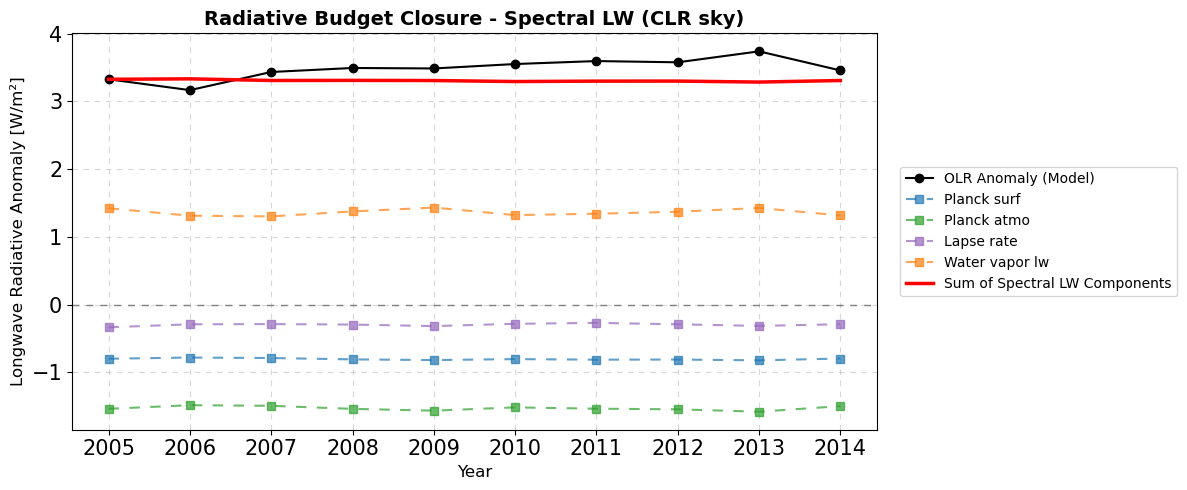

In [40]:
# Spectral LW Budget Closure

dRt_dict_spect = sfc.open_dRt(cart_out_spect, names=['planck-surf', 'planck-atmo', 'lapse-rate', 'water-vapor-lw'])

# Clear sky
out.plot_spectral_closure(
    experiment=experiment_sp, 
    dRt_dict=dRt_dict_spect, 
    title="Radiative Budget Closure", 
    sky="clr", 
    output_file=os.path.join(out_dir, "budget_closure_spectral_clr.png")
)